In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATASET_ROOT = Path("../data")

TRAIN_DIR = DATASET_ROOT / "train"
VALIDATION_DIR = DATASET_ROOT / "validation"
TEST_DIR = DATASET_ROOT / "test"

### Count images in each class

In [7]:
Image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

def count_images(split_dir):
    counts = {}

    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            count = sum(
                1 for file in class_dir.iterdir()
                if file.is_file() and file.suffix.lower() in Image_extensions
            )
            counts[class_dir.name] = count
    return counts

train_counts = count_images(TRAIN_DIR)
validation_counts = count_images(VALIDATION_DIR)
test_counts = count_images(TEST_DIR)

classes = sorted(train_counts.keys())

distribution_df = pd.DataFrame({
    "Class": classes,
    "Train": [train_counts[c] for c in classes],
    "Validation": [validation_counts[c] for c in classes],
    "Test": [test_counts[c] for c in classes]
})

In [8]:
total_train = distribution_df["Train"].sum()

distribution_df["Train_Percentage"] = (
    distribution_df["Train"] / total_train * 100
)

distribution_df

,Class,Train,Validation,Test,Train_Percentage
0,Buffalo,371,371,371,6.639227
1,Camel,411,392,388,7.355047
2,Cat,611,610,612,10.934145
3,Chicken,387,327,365,6.925555
4,Donkey,759,85,192,13.582677
5,Goat,742,98,192,13.278454
6,Horse,975,121,234,17.448103
7,Pig,644,89,181,11.524696
8,Sheep,688,88,181,12.312097


In [9]:
max_count = distribution_df["Train"].max()
min_count = distribution_df["Train"].min()

max_class = distribution_df.loc[
    distribution_df["Train"].idxmax(), "Class"
]

min_class = distribution_df.loc[
    distribution_df["Train"].idxmin(), "Class"
]

imbalance_ratio = max_count / min_count

print(f"Total training images: {total_train}")
print(f"Largest class : {max_class} ({max_count})")
print(f"Smallest class : {min_class} ({min_count})")
print(f"Imbalance ratio : {imbalance_ratio:.2f}x")

Total training images: 5588
Largest class : Horse (975)
Smallest class : Buffalo (371)
Imbalance ratio : 2.63x


In [10]:
num_classes = len(distribution_df)

# Balanced class weight:
# total_samples / (number_of_classes x samples_in_class)
distribution_df["Class_Weight"] = (
    total_train / (num_classes * distribution_df["Train"])
)

distribution_df.sort_values("Train")

,Class,Train,Validation,Test,Train_Percentage,Class_Weight
0,Buffalo,371,371,371,6.639227,1.673555
3,Chicken,387,327,365,6.925555,1.604364
1,Camel,411,392,388,7.355047,1.510679
2,Cat,611,610,612,10.934145,1.016185
7,Pig,644,89,181,11.524696,0.964113
8,Sheep,688,88,181,12.312097,0.902455
5,Goat,742,98,192,13.278454,0.836777
4,Donkey,759,85,192,13.582677,0.818035
6,Horse,975,121,234,17.448103,0.636809


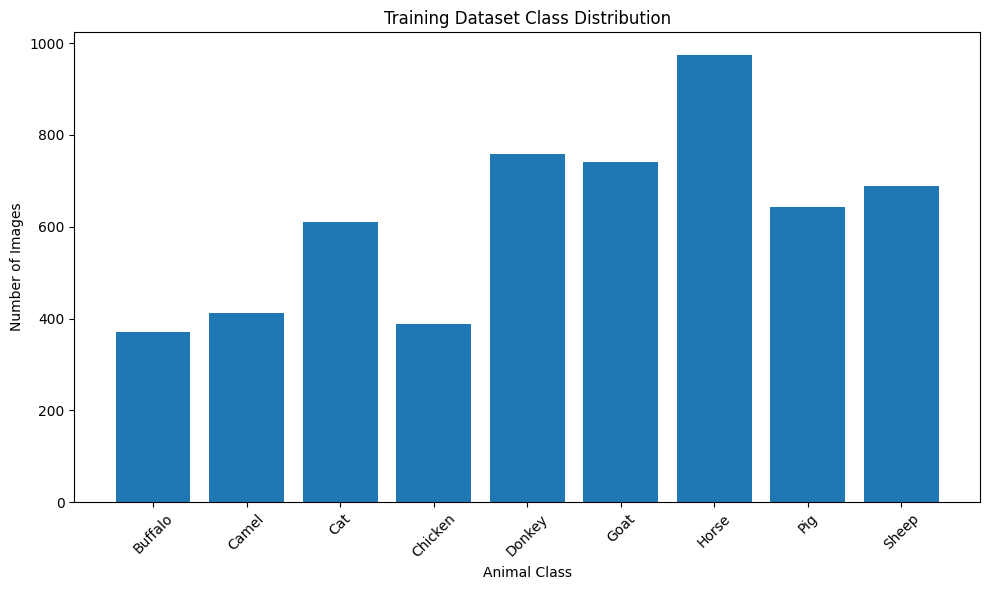

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    distribution_df["Class"],
    distribution_df["Train"]
)

plt.xlabel("Animal Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
print("=" * 50)
print("TRAINING DATASET CLASS BALANCE REPORT")
print("=" * 50)

for _, row in distribution_df.sort_values("Train").iterrows():
    print(
        f"{row['Class']:10s} : "
        f"{int(row['Train']):4d} images | "
        f"{row['Train_Percentage']:5.2f}% | "
        f"weight: {row['Class_Weight']:.3f}"
    )

print("-" * 50)
print(f"Total images      : {total_train}")
print(f"Largest class     : {max_class} ({max_count})")
print(f"Smallest class    : {min_class} ({min_count})")
print(f"Imbalance ratio   : {imbalance_ratio:.2f}x")
print("=" * 50)    

TRAINING DATASET CLASS BALANCE REPORT
Buffalo    :  371 images |  6.64% | weight: 1.674
Chicken    :  387 images |  6.93% | weight: 1.604
Camel      :  411 images |  7.36% | weight: 1.511
Cat        :  611 images | 10.93% | weight: 1.016
Pig        :  644 images | 11.52% | weight: 0.964
Sheep      :  688 images | 12.31% | weight: 0.902
Goat       :  742 images | 13.28% | weight: 0.837
Donkey     :  759 images | 13.58% | weight: 0.818
Horse      :  975 images | 17.45% | weight: 0.637
--------------------------------------------------
Total images      : 5588
Largest class     : Horse (975)
Smallest class    : Buffalo (371)
Imbalance ratio   : 2.63x
